In [1]:
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

from g2p_en import G2p
import re

from basicOperations.manifoldOperations import matrixDistance, frechetMean
import torch.nn.utils as utils

import math

import pickle
import Levenshtein
import os

import matplotlib.pyplot as plt
from IPython.display import Audio
import soundfile as sf

In [2]:
import sys, os
sys.path.insert(0, "/home/k2/src/textlesslib")  
import textless
print("textless loaded from:", textless.__file__)

import os, re, pathlib, torch, torchaudio
from textless.vocoders.tacotron2.vocoder import TacotronVocoder

textless loaded from: /home/k2/src/textlesslib/textless/__init__.py


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
vocoder = TacotronVocoder.by_name("hubert-base-ls960", "kmeans", 100).to(device)
srOut = vocoder.output_sample_rate
print("vocoder SR:", srOut, "| device:", device)

/home/k2/src/textlesslib/textless/vocoders/tacotron2/vocoder.py:118: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt_dict = torch.load(tacotron_model_path, map_location=t

vocoder SR: 22050 | device: cuda


In [4]:
"""
English phoneme definitions.
"""

tok2id = {}
with open("/mnt/dataDrive/emgFullCorpora/toUpload/DATA/ckptsLargeVocab/lang_phone/tokens.txt") as f:
    for line in f:
        s, i = line.strip().split()
        i = int(i)
        if s == "<eps>" or s.startswith("#"):
            continue
        tok2id[s] = i
PHONE_DEF = tok2id


def phoneToId(p):
    return PHONE_DEF[p]

g2p = G2p()

In [5]:
DATA = pickle.load(open("cleanData/DATA.pkl", "rb"))
unitLABELS = np.load("TTSdiscreteUnits100HuBERT.npy", allow_pickle = True)
phonemeLABELS = pickle.load(open("cleanData/LABELS.pkl", "rb"))

In [6]:
totalTime = 0 
for i in range(len(DATA)):
    totalTime += DATA[i].shape[1]/5000
print(totalTime/60)

50.93879666666667


In [7]:
totalWords = 0
for i in range(len(phonemeLABELS)):
    w = phonemeLABELS[i].split(" ")
    totalWords += len(w)
print(totalWords)

print(totalWords/(totalTime/60))

3111
61.07329194204888


In [8]:
MAX = max(len(u) for u in unitLABELS)
print(MAX)
unitizedLabels = np.zeros((len(unitLABELS), MAX), dtype = np.int64)
for i, seq in enumerate(unitLABELS):
    unitizedLabels[i, :len(seq)] = np.asarray(seq, dtype = np.int64)
unitLabelLengths = np.array([len(seq) for seq in unitLABELS], dtype = np.int32)

99


In [9]:
"""
Phonemize the sentences.
"""

phonemizedSentences = []

for i in range(len(phonemeLABELS)):
    phones = []
    for p in g2p(phonemeLABELS[i]): 
        p = re.sub(r'[0-9]', '', p)   
        if re.match(r'[A-Z]+', p): 
            phones.append(p)
    phonemizedSentences.append(phones)

"""
Convert phone-to-indices using look-up dictionary PHONE_DEF.
"""

phoneIndexedSentences = []
for i in range(len(phonemizedSentences)):
    current = phonemizedSentences[i]
    phoneID = []
    for j in range(len(current)):
        phoneID.append(phoneToId(current[j]))
    phoneIndexedSentences.append(phoneID)

def tokenIdToClassIdx(tokenId: int) -> int:
    return tokenId - 1   

def phoneSeqToClassIdxSeq(phoneSeq):
    return [tokenIdToClassIdx(PHONE_DEF[p]) for p in phoneSeq]

classIndexedSentences = [phoneSeqToClassIdxSeq(seq) for seq in phonemizedSentences]

MAX = max(len(u) for u in classIndexedSentences)
print(MAX)

"""
Pad the phone transcribed sentences to a common length (to be used with CTC loss).
"""

phonemizedLabels = np.zeros((len(classIndexedSentences), MAX)) - 1
for i in range(len(classIndexedSentences)):
    phonemizedLabels[i, 0:len(classIndexedSentences[i])] = classIndexedSentences[i]

labelLengths = np.zeros((len(classIndexedSentences)))
for i in range(len(classIndexedSentences)):
    labelLengths[i] = len(classIndexedSentences[i])

33


In [10]:
"""
z-normalize the data along the time dimension.
"""

normDATA = []
for i in range(len(DATA)):
    Mean = np.mean(DATA[i], axis = -1)
    Std = np.std(DATA[i], axis = -1)
    normDATA.append((DATA[i] - Mean[..., np.newaxis])/Std[..., np.newaxis])

In [11]:
from emgJitter import (
    computeConvSeq,
    EpochJitterEMGDataset,)
from torch.nn.utils.rnn import pad_sequence

In [12]:
@torch.no_grad()
def padCollateSpd(batch, C: int, padValue: int = -1):
    """
    batch: list of tuples:
      (covSeq, phoneSeq, phoneLen, unitSeq, unitLen)
    Returns:
      inputs: (N, T_max, C, C)
      phoneTargets: (N, Lp_max) [padded with padValue]
      unitTargets : (N, Lu_max) [padded with padValue]
      inputLengths : (N,)
      phoneTargetLengths: (N,)
      unitTargetLengths : (N,)
    """
    covSeqs, phoneSeqs, phoneLens, unitSeqs, unitLens = zip(*batch)
    B = len(batch)

    Tmax = max(int(x.shape[0]) for x in covSeqs)
    inputs = covSeqs[0].new_zeros((B, Tmax, C, C))
    I = torch.eye(C, dtype = inputs.dtype)
    for b, x in enumerate(covSeqs):
        Tb = int(x.shape[0])
        inputs[b, :Tb] = x
        if Tb < Tmax:
            inputs[b, Tb:Tmax] = I

    LpMax = max(int(L) for L in phoneLens)
    LuMax = max(int(L) for L in unitLens)

    phoneTargets = torch.full((B, LpMax), padValue, dtype = torch.long)
    unitTargets  = torch.full((B, LuMax), padValue, dtype = torch.long)

    for b, (p, Lp) in enumerate(zip(phoneSeqs, phoneLens)):
        p = torch.as_tensor(p).view(-1)
        phoneTargets[b, :int(Lp)] = p[:int(Lp)]

    for b, (u, Lu) in enumerate(zip(unitSeqs, unitLens)):
        u = torch.as_tensor(u).view(-1)
        unitTargets[b, :int(Lu)] = u[:int(Lu)]

    inputLengths        = torch.as_tensor([int(t.shape[0]) for t in covSeqs], dtype = torch.int32)
    phoneTargetLengths  = torch.as_tensor(phoneLens, dtype = torch.int32)
    unitTargetLengths   = torch.as_tensor(unitLens,  dtype = torch.int32)

    return (inputs, phoneTargets, unitTargets,
            inputLengths, phoneTargetLengths, unitTargetLengths)

In [297]:
"""numSentences = len(DATA)
numTest = 60

testIndices = np.random.choice(numSentences, size = numTest, replace = False)

np.save("testIndices.npy", testIndices)

for i in range(len(testIndices)):
    print(phonemeLABELS[testIndices[i]])"""

please dim the hallway lighting
the pillow feels cold again
my breathing is calming today
my breathing feels calmer now
my knee feels lighter tonight
my chest feels tense tonight
my leg feels stiff again
the mattress is improving today
the cushion feels tight again
i feel steady with your help
the humidifier feels calmer now
my chest feels better now
my ankle feels softer now
please wipe the camera lens gently
the sheet is improving slowly
the wheelchair feels warm again
please cool the pillow slightly
my back feels more stable
my leg is calming today
the pillow feels tight today
my shoulder is steady right now
please brighten the screen slightly now
the cushion feels swollen again
i feel warmth from the blanket
please center the communication device
the window feels stiff today
please open the window halfway
the mattress feels stiff again
the chair feels tight again
my muscles feel sore today
please lift my shoulders gently
could you lift my elbow slightly
my arm is relaxed now
i feel

In [13]:
def splitBYindices(data, trainIdx, valIdx, testIdx):
   
    dataList = list(data)
    train = [dataList[i] for i in trainIdx]
    val   = [dataList[i] for i in valIdx]
    test  = [dataList[i] for i in testIdx]
    return train, val, test


N = len(normDATA)         
testIdx = np.array(np.load("testIndices.npy"), dtype = int)

mask = np.ones(N, dtype = bool)
mask[testIdx] = False

remainingIdx = np.nonzero(mask)[0]      

nTrain = 500
trainIdx = remainingIdx[:nTrain]
valIdx   = remainingIdx[nTrain:]

print(len(trainIdx), len(valIdx), len(testIdx))

500 37 60


In [14]:
print(testIdx[57])
print(phonemeLABELS[537])

537
my chest feels more relaxed


In [15]:
duration = 0
for i in range(len(trainIdx)):
    duration += DATA[trainIdx[i]].shape[1]/5000
print(duration/60)

42.88394999999998


In [16]:
for i in range(len(testIdx)):
    query = phonemeLABELS[testIdx[i]]
    count = phonemeLABELS.count(query)
    if count > 1:
        print(i)

57


In [17]:
C = 31
fs = 5000
winMs, hopMs = 50.0, 30.0     
shrinkAlpha = 0.1
DIAG = False
diagOnly = False
Evec = np.load("eigenVectors.npy")  

emgTrain, emgVal, emgTest = splitBYindices(normDATA, trainIdx, valIdx, testIdx)

phTrain, phVal, phTest = splitBYindices(phonemizedLabels, trainIdx, valIdx, testIdx)
phLTrain, phLVal, phLTest = splitBYindices(labelLengths, trainIdx, valIdx, testIdx)

huTrain, huVal, huTest = splitBYindices(unitizedLabels, trainIdx, valIdx, testIdx)
huLTrain, huLVal, huLTest = splitBYindices(unitLabelLengths, trainIdx, valIdx, testIdx)

textTrain, textVal, textTest = splitBYindices(phonemeLABELS, trainIdx, valIdx, testIdx)


trainDS = EpochJitterEMGDataset(
    emgTrain, phTrain, phLTrain, huTrain, huLTrain,
    fs = fs, winMs = winMs, hopMs = hopMs,
    shrinkAlpha = shrinkAlpha, diag = DIAG, diagOnly = diagOnly, eigenvectors = Evec,
    jitter = True,
)
valDS = EpochJitterEMGDataset(
    emgVal, phVal, phLVal, huVal, huLVal,
    fs = fs, winMs = winMs, hopMs = hopMs,
    shrinkAlpha = shrinkAlpha, diag = DIAG, diagOnly = diagOnly, eigenvectors = Evec,
    jitter = False,
)
testDS = EpochJitterEMGDataset(
    emgTest, phTest, phLTest, huTest, huLTest,
    fs = fs, winMs = winMs, hopMs = hopMs,
    shrinkAlpha = shrinkAlpha, diag = DIAG, diagOnly = diagOnly, eigenvectors = Evec,
    jitter = False,
)
numWorkers = 4
trainLoader = DataLoader(
    trainDS, batch_size = 32, shuffle = True,
    num_workers = numWorkers, pin_memory = True,
    collate_fn = lambda b: padCollateSpd(b, C = 31),
)
valLoader = DataLoader(
    valDS, batch_size = 32, shuffle = False,
    num_workers = numWorkers, pin_memory = True,
    collate_fn = lambda b: padCollateSpd(b, C = 31),
)
testLoader = DataLoader(
    testDS, batch_size = 1, shuffle = False,
    num_workers = numWorkers, pin_memory = True,
    collate_fn = lambda b: padCollateSpd(b, C = 31),
)

In [18]:
PpGivenU = np.load("PpGivenU.npy")[:, 1:]
phoneBlank = 40; unitBlank = 100
Anb = PpGivenU.astype(np.float64) + 1e-6
Anb /= Anb.sum(axis = 0, keepdims = True)

P, Unonblank = Anb.shape
Afull = np.zeros((P, Unonblank + 1), dtype = np.float32)
Afull[:, :Unonblank] = Anb
Afull[:, Unonblank]  = 0.0
Afull[phoneBlank, Unonblank] = 1.0

A = torch.tensor(Afull, dtype = torch.float32, device=device)

In [19]:
def consistencyLoss(
    unitLogprobs: torch.Tensor,    # (T,N,U)  log-softmax from unit head
    phoneLogprobs: torch.Tensor,   # (T,N,P)  log-softmax from phone head
    A: torch.Tensor,               # (P,U) 
    *,
    lengths: torch.Tensor | None = None,  
    phoneBlank: int = 40,
    tau: float = 1.0,              
    alpha: float = 0.0,            
    excludeBlank: bool = True,
    weightByNonblank: bool = True,
    gamma: float = 1.0,            
    topkA: int | None = None,    
    logFloor: float = -20.0      
) -> torch.Tensor:
    """
    Computes a framewise divergence between:
      p_p(t)  = p(phone | EMG)            <- phone head
      p̂_p(t) = A p(unit | EMG)            <- phone-from-units via A
      "ce" : H( p_p || p̂_p ) = -E_{p_p}[ log p̂_p ]      
    """

    eps = 1e-8
    dev = unitLogprobs.device
    P  = phoneLogprobs.size(-1)

    A = A.to(dev, dtype = torch.float32).clamp_min(1e-8)  
    if topkA is not None and 0 < topkA < P:
        idx = torch.topk(A, k = topkA, dim = 0).indices      
        mask = torch.zeros_like(A, dtype = torch.bool)
        mask.scatter_(0, idx, True)
        A = torch.where(mask, A, torch.zeros_like(A))
        A = A / A.sum(dim = 0, keepdim = True).clamp_min(eps)

    logA = torch.log(A) 
    logPhat = torch.logsumexp(
        unitLogprobs.unsqueeze(-2) + logA.unsqueeze(0).unsqueeze(0),
        dim = -1
    )  
    logpP = phoneLogprobs
    if tau != 1.0:
        logpP = torch.log_softmax(logpP / tau, dim = -1)

    if excludeBlank:
        keep = torch.ones(P, dtype = torch.bool, device = dev)
        keep[phoneBlank] = False
        logpP    = logpP[..., keep]   
        logPhat = logPhat[..., keep]   
        Peff = logpP.size(-1)
    else:
        Peff = P

    logpP = logpP - torch.logsumexp(logpP, dim = -1, keepdim = True)
    logPhat = logPhat - torch.logsumexp(logPhat, dim = -1, keepdim = True)

    
    if alpha > 0.0:
        pP = logpP.exp()  
        prior = torch.full_like(pP, 1.0 / Peff)
        pP = (1.0 - alpha) * pP + alpha * prior
        pP = pP / pP.sum(dim = -1, keepdim = True).clamp_min(eps)
        logpPtarget = torch.log(pP.clamp_min(eps)).detach()
        pPtarget    = pP.detach()
    else:
        logpPtarget = logpP.detach()
        pPtarget    = logpP.exp().detach()

    if weightByNonblank:
        pBlank = phoneLogprobs.exp().detach()[..., phoneBlank]
        w = (1.0 - pBlank).pow(gamma)
    else:
        w = None

   
    per = -(pPtarget * torch.clamp(logPhat, min = logFloor)).sum(dim = -1) 

    if lengths is not None:
        T, N = per.shape
        L = lengths.to(dev, dtype = torch.long)
        mask = (torch.arange(T, device = dev).unsqueeze(1) < L.unsqueeze(0)).float()  
        if w is not None:
            per = per * w
            denom = (mask * w).sum().clamp_min(1.0)
        else:
            denom = mask.sum().clamp_min(1.0)
        return (per * mask).sum() / denom
    else:
        return (per * w).mean() if w is not None else per.mean()

In [43]:
def _concatTargets(padded: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:
    assert padded.ndim == 2 and lengths.ndim == 1
    return torch.cat([padded[b, :int(L)] for b, L in enumerate(lengths.tolist())],
                     dim = 0).to(dtype = torch.long, copy = False)

def trainOperation(model, device, trainLoader, optimizer, ctcUnit, ctcPhone,
                   A, lambdaUnit, lambdaPhone, lambdaCons,
                   epochIdx = 1, rampEpochs = 5, phoneBlank = 40, unitBlank = 100, maxGradNorm = 1.0,
                   consTau = 1.2, consExcludeBlank = True, consWeightByNonblank = True, consGamma = 1.0, alpha = 0.0):
    """
      lossC = D( p(phone|EMG) || A p(unit|EMG) )
    """
    model.train()
    total = totalU = totalP = totalC = 0.0
    ramp = min(1.0, float(epochIdx) / max(1, rampEpochs))

    A = A.to(device = device, dtype = torch.float32)

    for (inputs, phoneTgts, unitTgts, inLens, phoneLens, unitLens) in trainLoader:
        inputs     = inputs.to(device, non_blocking = True)
        phoneTgts  = phoneTgts.to(device, non_blocking = True)
        unitTgts   = unitTgts.to(device, non_blocking = True)
        inLens     = inLens.to(device, dtype = torch.long, non_blocking = True)
        phoneLens  = phoneLens.to(device, dtype = torch.long, non_blocking = True)
        unitLens   = unitLens.to(device, dtype = torch.long, non_blocking = True)

        phoneTargets1d = _concatTargets(phoneTgts, phoneLens)
        unitTargets1d  = _concatTargets(unitTgts,  unitLens)

        optimizer.zero_grad(set_to_none = True)

        out   = model(inputs)
        logpU = out['unit_logprobs']   # (T,N,101)
        logpP = out['phone_logprobs']  # (T,N,41)

        lossU = ctcUnit(logpU, unitTargets1d, inLens, unitLens)
        lossP = ctcPhone(logpP, phoneTargets1d, inLens, phoneLens)

        """lossC = consistencyLoss(
            unitLogprobs = logpU,
            phoneLogprobs = logpP,
            A = A,
            lengths = inLens,
            phoneBlank = phoneBlank,
            tau = consTau,
            excludeBlank = consExcludeBlank,
            weightByNonblank = consWeightByNonblank,
            gamma = consGamma,
            alpha = alpha
        )"""

        loss = lambdaUnit * lossU + lambdaPhone * lossP #+ lambdaCons * lossC
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), maxGradNorm)
        optimizer.step()

        total  += float(loss.item())
        totalU += float(lossU.item())
        totalP += float(lossP.item())
        #totalC += float(lossC.item())

    n = max(1, len(trainLoader))
    return total/n, (totalU/n, totalP/n)#, totalC/n)


@torch.no_grad()
def valOperation(model, device, valLoader, ctcUnit, ctcPhone,
                 A, lambdaUnit, lambdaPhone, lambdaCons,
                 epochIdx = 1, rampEpochs = 5, phoneBlank = 40, unitBlank = 100,
                 consTau = 1.2, consExcludeBlank = True, consWeightByNonblank = True, consGamma = 1.0, alpha = 0.0):
    model.eval()
    total = totalU = totalP = totalC = 0.0
    ramp = min(1.0, float(epochIdx) / max(1, rampEpochs))
    A = A.to(device = device, dtype = torch.float32)

    for (inputs, phoneTgts, unitTgts, inLens, phoneLens, unitLens) in valLoader:
        inputs     = inputs.to(device, non_blocking = True)
        phoneTgts  = phoneTgts.to(device, non_blocking = True)
        unitTgts   = unitTgts.to(device, non_blocking = True)
        inLens     = inLens.to(device, dtype = torch.long, non_blocking = True)
        phoneLens  = phoneLens.to(device, dtype = torch.long, non_blocking = True)
        unitLens   = unitLens.to(device, dtype = torch.long, non_blocking = True)

        phoneTargets1d = _concatTargets(phoneTgts, phoneLens)
        unitTargets1d  = _concatTargets(unitTgts,  unitLens)

        out   = model(inputs)
        logpU = out['unit_logprobs']
        logpP = out['phone_logprobs']

        lossU = ctcUnit(logpU, unitTargets1d, inLens, unitLens)
        lossP = ctcPhone(logpP, phoneTargets1d, inLens, phoneLens)

        """lossC = consistencyLoss(
            unitLogprobs = logpU,
            phoneLogprobs = logpP,
            A = A,
            lengths = inLens,
            phoneBlank = phoneBlank,
            tau = consTau,
            excludeBlank = consExcludeBlank,
            weightByNonblank = consWeightByNonblank,
            gamma = consGamma,
            alpha = alpha
        )"""

        loss = lambdaUnit * lossU + lambdaPhone * lossP #+ ramp * lambdaCons * lossC

        total  += float(loss.item())
        totalU += float(lossU.item())
        totalP += float(lossP.item())
        #totalC += float(lossC.item())

    n = max(1, len(valLoader))
    return total/n, (totalU/n, totalP/n)#, totalC/n)


In [44]:
import convModule
from torch.optim.lr_scheduler import CosineAnnealingLR, SequentialLR, LinearLR

In [45]:
dev = "cuda:0"
device = torch.device(dev)

numberEpochs = 100


model = convModule.DualHeadTDSCTC(
    in_features        = 31 * 31,        
    mlp_features       = [384],
    block_channels     = [24, 24, 24, 24],
    kernel_width       = 14,
    num_units          = 101,           
    num_phones         = 41,            
    unit_blank         = 100,           
    phone_blank        = 40,             
    electrode_channels = 31,
    bottleneck_dim = 512
).to(device)

numParams = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"#params: {numParams:,}")

ctcUnit  = nn.CTCLoss(blank = 100, zero_infinity = True) 
ctcPhone = nn.CTCLoss(blank = 40,  zero_infinity = True)  

rnnOptimizer = optim.AdamW(
    model.parameters(), lr = 3e-4, weight_decay = 1e-4, betas = (0.9, 0.98)
)

warmup = 5
sched = torch.optim.lr_scheduler.SequentialLR(
    rnnOptimizer,
    schedulers = [
        torch.optim.lr_scheduler.LinearLR(rnnOptimizer, start_factor = 0.1, total_iters = warmup),
        torch.optim.lr_scheduler.CosineAnnealingLR(rnnOptimizer, T_max = numberEpochs - warmup, eta_min = 1e-6),
    ],
    milestones = [warmup],
)

#params: 1,861,420


In [46]:
lambdaUnit  = 0.8
lambdaPhone = 0.1
lambdaConsTarget = 0.1  
valLOSS = []

for epoch in range(1, numberEpochs + 1):

    trainDS.resampleJitter(seed=None)

    trainLoss, allLoss = trainOperation(
        model, device, trainLoader, rnnOptimizer,
        ctcUnit, ctcPhone,
        A,
        lambdaUnit, lambdaPhone, lambdaConsTarget, 
        epochIdx = epoch, rampEpochs = warmup,
        phoneBlank = 40, unitBlank = 100,
        consTau = 1, 
        consExcludeBlank = True, consWeightByNonblank = True, consGamma = 1.0, alpha = 0
    )

    valLoss, v = valOperation(
        model, device, valLoader,
        ctcUnit, ctcPhone,
        A,
        lambdaUnit, lambdaPhone, lambdaConsTarget,
        epochIdx = epoch, rampEpochs = warmup,
        phoneBlank = 40, unitBlank = 100,
        consTau = 1, 
        consExcludeBlank = True, consWeightByNonblank = True, consGamma = 1.0, alpha = 0
    )

    sched.step()

    valLOSS.append(valLoss)
    torch.save(model.state_dict(), f"ckpts/largeVocabConv/{epoch}.pt")

    print(allLoss)
    print(v)
    print(f"Epoch {epoch}/{numberEpochs}  Train {trainLoss:.4f}  Val {valLoss:.4f}\n")

(10.764278948307037, 26.675814747810364)
(8.819072246551514, 25.5158748626709)
Epoch 1/100  Train 11.2790  Val 9.6068

(7.715335845947266, 22.706409096717834)
(5.483883380889893, 18.070528984069824)
Epoch 2/100  Train 8.4429  Val 6.1942

(4.844857543706894, 10.760015219449997)
(4.540836572647095, 4.029165267944336)
Epoch 3/100  Train 4.9519  Val 4.0356

(4.426292568445206, 3.732775554060936)
(4.391450643539429, 3.5018151998519897)
Epoch 4/100  Train 3.9143  Val 3.8633

(4.375636637210846, 3.4448560178279877)
(4.399764776229858, 3.4444440603256226)
Epoch 5/100  Train 3.8450  Val 3.8643



/home/k2/miniconda3/envs/emgSpeech/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:232: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


(4.349738746881485, 3.4022005945444107)
(4.305603504180908, 3.3969017267227173)
Epoch 6/100  Train 3.8200  Val 3.7842

(4.266031831502914, 3.385759085416794)
(4.18315577507019, 3.351384997367859)
Epoch 7/100  Train 3.7514  Val 3.6817

(4.177782356739044, 3.3377189934253693)
(4.1579365730285645, 3.291255831718445)
Epoch 8/100  Train 3.6760  Val 3.6555

(4.0987908244133, 3.30098357796669)
(4.011213541030884, 3.232261300086975)
Epoch 9/100  Train 3.6091  Val 3.5322

(4.001976490020752, 3.2645921260118484)
(3.882364511489868, 3.1600992679595947)
Epoch 10/100  Train 3.5280  Val 3.4219

(3.9253112077713013, 3.2280945479869843)
(3.865914225578308, 3.1597201824188232)
Epoch 11/100  Train 3.4631  Val 3.4087

(3.849985718727112, 3.1963902413845062)
(3.737975239753723, 3.094218134880066)
Epoch 12/100  Train 3.3996  Val 3.2998

(3.7620089650154114, 3.15737621486187)
(3.636149048805237, 3.035265803337097)
Epoch 13/100  Train 3.3253  Val 3.2124

(3.6728159338235855, 3.1212064623832703)
(3.5025954246

In [48]:
np.save("ckpts/largeVocabConv/valLoss.npy", valLOSS)

In [49]:
valLoss = np.load("ckpts/largeVocabConv/valLoss.npy")
print(np.min(valLoss))
print(np.argmin(valLoss) + 1)
epoch = np.argmin(valLoss)

1.4129620790481567
59


In [50]:
@torch.no_grad()
def testOperation(
    model,
    device,
    testLoader,
    ctcUnit,                         
    ctcPhone,                       
    lambdaPhone: float = 0.3,
):
    
    model.eval()
    outputsList = []

    lossUtotal = 0.0
    lossPtotal = 0.0
    lossTotal   = 0.0
    numBatches  = 0

    for (inputs, phoneTgts, unitTgts, inLens, phoneLens, unitLens) in testLoader:
        
        inputs     = inputs.to(device)        
        phoneTgts  = phoneTgts.to(device)    
        unitTgts   = unitTgts.to(device)     
        inLens     = inLens.to(device)       
        phoneLens  = phoneLens.to(device)     
        unitLens   = unitLens.to(device)      
        phoneTargets1d = _concatTargets(phoneTgts, phoneLens)
        unitTargets1d  = _concatTargets(unitTgts,  unitLens)

       
        out   = model(inputs)               
        logpU = out["unit_logprobs"]
        logpP = out["phone_logprobs"]

        batchLossU = ctcUnit(logpU, unitTargets1d, inLens, unitLens)
        batchLossP = ctcPhone(logpP, phoneTargets1d, inLens, phoneLens)
        batchLoss   = (1.0 - lambdaPhone) * batchLossU + lambdaPhone * batchLossP

        batchDict = {
            "unit_logprobs":  logpU.transpose(0, 1).detach().cpu(),   
            "phone_logprobs": logpP.transpose(0, 1).detach().cpu(),   
        }
        outputsList.append(batchDict)

        lossUtotal += float(batchLossU.item())
        lossPtotal += float(batchLossP.item())
        lossTotal   += float(batchLoss.item())
        numBatches  += 1

    metrics = {
        "loss_unit":  lossUtotal / max(1, numBatches),
        "loss_phone": lossPtotal / max(1, numBatches),
        "loss_total": lossTotal   / max(1, numBatches),
    }
    return outputsList, metrics

In [54]:
modelWeight = torch.load("ckpts/largeVocabConv/" + str(59)  + '.pt', weights_only = True)
model.load_state_dict(modelWeight)

<All keys matched successfully>

In [55]:
outputs, metrics = testOperation(
    model, device, testLoader,
    ctcUnit, ctcPhone, lambdaPhone = 0.3
)

print(metrics)

{'loss_unit': 1.74973004758358, 'loss_phone': 1.450964870552222, 'loss_total': 1.660100488861402}


In [56]:
"""
Simple beam-search algorithm.
"""

def ctcPrefixBeamSearch(
    logProbs,
    testLen = None,
    beamSize = 5,
    blank = 100,
    topk = None,
    allowDoubles = True,
):
    
    lp = np.asarray(logProbs)
    Ttotal, V = lp.shape
    T = Ttotal if testLen is None else int(min(testLen, Ttotal))

    beams = {(): (0.0, -np.inf)}

    def add(store, seq, addPb, addPnb):
        if seq in store:
            pb, pnb = store[seq]
            if addPb  != -np.inf: pb  = np.logaddexp(pb,  addPb)
            if addPnb != -np.inf: pnb = np.logaddexp(pnb, addPnb)
            store[seq] = (pb, pnb)
        else:
            store[seq] = (addPb, addPnb)

    for t in range(T):
        row = lp[t] 
        new = {}

        if topk is not None and topk < V:
            cand = np.argpartition(row, -topk)[-topk:]
            if blank not in cand:
                worstIdx = cand[np.argmin(row[cand])]
                cand[cand == worstIdx] = blank
        else:
            cand = range(V)

        for seq, (pb, pnb) in beams.items():
            add(new, seq, np.logaddexp(pb, pnb) + row[blank], -np.inf)

            last = seq[-1] if seq else None

            for c in cand:
                if c == blank:
                    continue
                pC = row[c]

                if c == last:
            
                    add(new, seq, -np.inf, pnb + pC)

                    if allowDoubles:
                        add(new, seq + (c,), -np.inf, pb + pC)
                else:
                    add(new, seq + (c,), -np.inf, np.logaddexp(pb, pnb) + pC)

        if len(new) > beamSize:
            items = sorted(new.items(),
                           key = lambda kv: np.logaddexp(*kv[1]),
                           reverse = True)[:beamSize]
            beams = dict(items)
        else:
            beams = new

    bestSeq = max(beams.items(), key = lambda kv: np.logaddexp(*kv[1]))[0]
    return bestSeq

def findClosestTranscription(decodedTranscript, phoneticTranscription):
    
    dist = Levenshtein.distance(decodedTranscript, phoneticTranscription)

    return dist

In [57]:
LEVS = []
decodedOut = []
for i in range(60):
    logp = outputs[i]["unit_logprobs"] 
    logpNp = logp.squeeze(0).numpy() 
    print(i)
    decodedSymbols = ctcPrefixBeamSearch(
    logProbs = logpNp,    
    beamSize = 1
) 
    decodedOut.append(decodedSymbols)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59


In [58]:
def findClosestTranscription(decodedTranscript, phoneticTranscription):
    
    dist = Levenshtein.distance(decodedTranscript, phoneticTranscription)

    return dist

In [59]:
levs = []
unitLENGTHS = []
for i in range(len(decodedOut)):
    unitLENGTHS.append(unitLabelLengths[testIdx[i]])
    levs.append(findClosestTranscription(decodedOut[i], unitizedLabels[testIdx[i]][:int(unitLabelLengths[testIdx[i]])]))
LEVS.append(np.mean(levs))

In [60]:
print(np.array(levs)/np.array(unitLENGTHS))

[0.50980392 0.34782609 0.42307692 0.32758621 0.45762712 0.36764706
 0.36842105 0.52       0.2745098  0.63043478 0.60714286 0.42307692
 0.53846154 0.57142857 0.62       0.36       0.36538462 0.32653061
 0.45833333 0.15555556 0.47272727 0.51428571 0.50847458 0.6
 0.62162162 0.44230769 0.54       0.54385965 0.50980392 0.34545455
 0.49180328 0.58181818 0.29545455 0.36231884 0.26829268 0.56
 0.53731343 0.56896552 0.41071429 0.61290323 0.41428571 0.625
 0.56140351 0.39285714 0.47368421 0.45       0.30612245 0.34615385
 0.41304348 0.51724138 0.45283019 0.40740741 0.34883721 0.38461538
 0.30232558 0.44897959 0.62       0.45454545 0.54166667 0.50847458]


In [616]:
np.save("levsPhoneGuide.npy", np.array(levs)/np.array(unitLENGTHS))

In [61]:
print("Mean length of sentences: ", np.mean(unitLENGTHS))
print("Mean phoneme errors (insertion errors + deletion errors + substitution errors): ", np.mean(levs))
print("Percent phoneme error: ", np.sum(levs)/np.sum(unitLENGTHS))

Mean length of sentences:  54.46666666666667
Mean phoneme errors (insertion errors + deletion errors + substitution errors):  25.133333333333333
Percent phoneme error:  0.4614443084455324


In [62]:
with open("cleanData/LABELS.pkl", "rb") as file:
    textLABELS = pickle.load(file)

In [63]:
indices = np.argsort(np.array(levs)/np.array(unitLENGTHS))
print(indices)

[19 34  8 32 54 46 17  3 29 47  1 52 15 33 16  5  6 53 43 51 38 48 40 11
  2 25 55 45 50 57  4 18 20 44 30 59 22  0 28 21 49  7 36 12 26 58 27 35
 42 37 13 31 23 10 39 56 14 24 41  9]


In [64]:
which = 6

In [65]:
print(decodedOut[which])
print(huTest[which][:huLTest[which]])

(50, 24, 13, 58, 44, 90, 35, 87, 9, 74, 2, 89, 3, 77, 11, 45, 64, 53, 19, 29, 6, 36, 92, 31, 23, 38, 65, 3, 77, 1, 74, 27, 89, 98, 87, 38, 44, 80, 81, 83, 57, 84, 72, 20)
[71 50 24 13 58  9 44 80 90 35 87  9 43 74  2 78 65  3 77 45 64 53 97 19
 29 28 10 92 10 57 10  6 36 92 31 23 53 65  6  3 77 23 73  1 27 89 87 38
 42 44 80 81 83 57 84 72 20]


In [66]:
print(levs[which]/unitLENGTHS[which])

0.3684210526315789


In [67]:
for i in range(len(decodedOut)):
    print(i)
    units = torch.tensor(decodedOut[i], dtype = torch.long, device = device)
    wav = vocoder(units).cpu().numpy()
    sf.write(
        f"audioFiles/{i}.wav",
        wav,
        vocoder.output_sample_rate
    )

0


/home/k2/src/textlesslib/textless/vocoders/tacotron2/audio_processing.py:82: FutureWarning: Pass size=1024 as keyword args. From version 0.10 passing these as positional arguments will result in an error
  win_sq = librosa_util.pad_center(win_sq, n_fft)


1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59


In [68]:
units = torch.tensor(decodedOut[which], dtype = torch.long, device = device)
wav = vocoder(units) 

In [70]:
Audio(wav.cpu().numpy(), rate = 22050)

In [520]:
for i in range(len(testIdx)):
    print(textLABELS[testIdx[i]])

please dim the hallway lighting
the pillow feels cold again
my breathing is calming today
my breathing feels calmer now
my knee feels lighter tonight
my chest feels tense tonight
my leg feels stiff again
the mattress is improving today
the cushion feels tight again
i feel steady with your help
the humidifier feels calmer now
my chest feels better now
my ankle feels softer now
please wipe the camera lens gently
the sheet is improving slowly
the wheelchair feels warm again
please cool the pillow slightly
my back feels more stable
my leg is calming today
the pillow feels tight today
my shoulder is steady right now
please brighten the screen slightly now
the cushion feels swollen again
i feel warmth from the blanket
please center the communication device
the window feels stiff today
please open the window halfway
the mattress feels stiff again
the chair feels tight again
my muscles feel sore today
please lift my shoulders gently
could you lift my elbow slightly
my arm is relaxed now
i feel

In [93]:
print(textLABELS[8000 + 1521])

im the only one


In [172]:
emgTrain, emgVal, emgTest = normDATA[:7000],     normDATA[7000:8000],     normDATA[8000:]
phTrain,  phVal,  phTest  = phonemizedLabels[:7000], phonemizedLabels[7000:8000], phonemizedLabels[8000:]
phLTrain, phLVal, phLTest = labelLengths[:7000],    labelLengths[7000:8000],    labelLengths[8000:]

huTrain,  huVal,  huTest  = unitizedLabels[:7000], unitizedLabels[7000:8000], unitizedLabels[8000:]
huLTrain, huLVal, huLTest = unitLabelLengths[:7000], unitLabelLengths[7000:8000], unitLabelLengths[8000:]

trainDS = EpochJitterEMGDataset(
    emgTrain, phTrain, phLTrain, huTrain, huLTrain,
    fs = fs, winMs = winMs, hopMs = hopMs,
    shrinkAlpha = shrinkAlpha, diag = DIAG, diagOnly = diagOnly, eigenvectors = Evec,
    jitter = True,
)
valDS = EpochJitterEMGDataset(
    emgVal, phVal, phLVal, huVal, huLVal,
    fs = fs, winMs = winMs, hopMs = hopMs,
    shrinkAlpha = shrinkAlpha, diag = DIAG, diagOnly = diagOnly, eigenvectors = Evec,
    jitter = False,
)
testDS = EpochJitterEMGDataset(
    emgTest, phTest, phLTest, huTest, huLTest,
    fs = fs, winMs = winMs, hopMs = hopMs,
    shrinkAlpha = shrinkAlpha, diag = DIAG, diagOnly = diagOnly, eigenvectors = Evec,
    jitter = False,
)
numWorkers = 4
trainLoader = DataLoader(
    trainDS, batch_size = 1, shuffle = False,
    num_workers = numWorkers, pin_memory = True,
    collate_fn = lambda b: padCollateSpd(b, C = 31),
)
valLoader = DataLoader(
    valDS, batch_size = 1, shuffle = False,
    num_workers = numWorkers, pin_memory = True,
    collate_fn = lambda b: padCollateSpd(b, C = 31),
)
testLoader = DataLoader(
    testDS, batch_size = 1, shuffle = False,
    num_workers = numWorkers, pin_memory = True,
    collate_fn = lambda b: padCollateSpd(b, C = 31),
)

In [173]:
outputsTrain, metricsTrain = testOperation(
    model, device, trainLoader,
    ctcUnit, ctcPhone, lambdaPhone = 0.3
)

outputsVal, metricsVal = testOperation(
    model, device, valLoader,
    ctcUnit, ctcPhone, lambdaPhone = 0.3
)


print(metricsTrain)
print(metricsVal)

{'loss_unit': 1.3017417279652186, 'loss_phone': 1.2017675570973327, 'loss_total': 1.2717494779654912}
{'loss_unit': 1.768291967689991, 'loss_phone': 1.6309849690496923, 'loss_total': 1.7270998685956}


In [ ]:
decodedOutTrainVal = []
for i in range(len(outputsTrain)):
    logp = outputsTrain[i]["unit_logprobs"] 
    logpNp = logp.squeeze(0).numpy() 
    print(i)
    decodedSymbols = ctcPrefixBeamSearch(
    logProbs = logpNp,    
    beamSize = 1,
) 
    decodedOutTrainVal.append(decodedSymbols)

for i in range(len(outputsVal)):
    logp = outputsVal[i]["unit_logprobs"] 
    logpNp = logp.squeeze(0).numpy() 
    print(i)
    decodedSymbols = ctcPrefixBeamSearch(
    logProbs = logpNp,    
    beamSize = 5,
) 
    decodedOutTrainVal.append(decodedSymbols)

In [176]:
levs = []
unitLENGTHS = []
for i in range(len(decodedOutTrainVal)):
    unitLENGTHS.append(unitLabelLengths[i])
    levs.append(findClosestTranscription(decodedOutTrainVal[i], unitizedLabels[i][:int(unitLabelLengths[i])]))
print("Mean length of sentences: ", np.mean(unitLENGTHS))
print("Mean phoneme errors (insertion errors + deletion errors + substitution errors): ", np.mean(levs))
print("Percent phoneme error: ", np.sum(levs)/np.sum(unitLENGTHS))

Mean length of sentences:  83.629375
Mean phoneme errors (insertion errors + deletion errors + substitution errors):  40.467625
Percent phoneme error:  0.483892471993244


In [189]:
which = 2
print(decodedOutTrainVal[which])
print(unitLABELS[which])

(71, 12, 57, 4, 34, 39, 67, 54, 93, 66, 31, 87, 62, 6, 36, 49, 92, 27, 47, 52, 85, 94, 32, 64, 16, 77, 53, 18, 66, 27, 47, 94, 64, 74, 27, 98, 69, 19, 6, 36, 49, 92, 10, 37, 86, 53, 44, 80, 18, 65, 3, 77, 24, 68, 43, 6, 36, 49, 92, 66, 31, 53, 16, 77, 62, 65, 6, 95, 23, 44, 80, 18, 66, 50, 47, 24, 13, 91, 43, 74, 2, 27, 31, 95, 23, 62, 6, 28, 36, 49, 41, 84, 93, 26, 91, 9, 74, 89, 6, 36, 92, 27, 89, 37, 53, 64, 6, 7, 11, 45, 64, 29, 28, 80, 81, 83, 22, 57, 20, 57)
[71, 12, 4, 12, 4, 84, 12, 63, 12, 57, 96, 34, 39, 67, 54, 93, 66, 82, 87, 62, 6, 15, 49, 92, 27, 47, 76, 90, 85, 87, 94, 32, 64, 16, 74, 77, 23, 53, 65, 1, 66, 27, 47, 11, 45, 64, 66, 98, 69, 19, 29, 6, 28, 49, 92, 27, 37, 86, 53, 44, 80, 18, 65, 3, 77, 24, 61, 43, 6, 36, 49, 92, 66, 31, 53, 69, 16, 77, 11, 64, 29, 95, 23, 42, 44, 80, 18, 50, 24, 13, 58, 43, 74, 2, 21, 95, 23, 5, 62, 29, 6, 28, 15, 49, 41, 84, 37, 40, 57, 86, 44, 80, 26, 87, 9, 74, 27, 89, 65, 95, 92, 31, 37, 10, 6, 15, 36, 7, 45, 64, 29, 28, 7, 23, 42, 80, 

In [197]:
units = torch.tensor(decodedOutTrainVal[which], dtype = torch.long, device = device)
wav = vocoder(units) 

/home/k2/src/textlesslib/textless/vocoders/tacotron2/audio_processing.py:82: FutureWarning: Pass size=1024 as keyword args. From version 0.10 passing these as positional arguments will result in an error
  win_sq = librosa_util.pad_center(win_sq, n_fft)


In [198]:
Audio(wav.cpu().numpy(), rate = 22050)

In [193]:
HuBERT_Audio_1 = []
for which in range(8000):
    print(which)
    units = torch.tensor(decodedOutTrainVal[which], dtype = torch.long, device = device)
    wav = vocoder(units) 
    wav = wav.cpu().numpy()
    HuBERT_Audio_1.append(wav)

0


/home/k2/src/textlesslib/textless/vocoders/tacotron2/audio_processing.py:82: FutureWarning: Pass size=1024 as keyword args. From version 0.10 passing these as positional arguments will result in an error
  win_sq = librosa_util.pad_center(win_sq, n_fft)


1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277


In [202]:
with open("HuBERT_Audio_1.pkl", "wb") as f:
    pickle.dump(HuBERT_Audio_1, f, protocol = pickle.HIGHEST_PROTOCOL)

In [201]:
Audio(HuBERT_Audio_1[2], rate = 22050)

In [133]:
def plotMelSpectrogram(
    wav: torch.Tensor,
    *,
    origSr: int = 22050,
    targetSr: int = 16000,
    nFft: int = 512,
    nMels: int = 120,
    hopLength: int | None = None,
    fMin: float = 30.0,
    fMax: float | None = None,          
    normalized: bool = False,             
    power: float = 2.0,                   
    logFloor: float = 1e-7,            
    device: str | torch.device = "cpu",
    channel: int | None = 0,             
    show: bool = True,
):
   
    if hopLength is None:
        hopLength = nFft // 4
    if fMax is None:
        fMax = targetSr / 2 - 100.0

    if wav.dtype == torch.int16:
        wav = wav.to(torch.float32) / 32768.0
    else:
        wav = wav.to(torch.float32)

    if wav.ndim == 1:
        wav = wav.unsqueeze(0) 
    wav = wav.to(device)

    wav = (wav - wav.mean(dim = -1, keepdim = True)) / (wav.std(dim = -1, keepdim = True) + 1e-8)

    if origSr != targetSr:
        resampler = torchaudio.transforms.Resample(orig_freq = origSr, new_freq = targetSr).to(device)
        wav = resampler(wav)  
    melTf = torchaudio.transforms.MelSpectrogram(
        sample_rate = targetSr,
        n_fft = nFft,
        hop_length = hopLength,
        n_mels = nMels,
        f_min = fMin,
        f_max = fMax,
        normalized = normalized,
        power = power,
        mel_scale = "slaney",
        norm = "slaney"
    ).to(device)

    with torch.no_grad():
        melspec = melTf(wav)  
    melspec = torch.log10(torch.clamp_min(melspec, logFloor))

    if channel is None:
        spec2plot = melspec.mean(dim = 0)
    else:
        spec2plot = melspec[channel]

    frames = spec2plot.shape[-1]
    timeAxis = np.arange(frames) * (hopLength / float(targetSr))

    melFb = torchaudio.functional.melscale_fbanks(
        n_freqs = nFft // 2 + 1,
        f_min = fMin,
        f_max = fMax,
        n_mels = nMels,
        sample_rate = targetSr,
        norm = "slaney",
        mel_scale = "slaney"
    ).to(device)

    domFftBin = melFb.argmax(dim = 0) 
    approxFreqHz = (domFftBin.float().cpu().numpy()) * (targetSr / float(nFft))

    if show:
        plt.figure(figsize = (10, 4))
        plt.imshow(
            spec2plot.detach().cpu().numpy(),
            aspect = "auto",
            origin = "lower",
            extent = [timeAxis[0], timeAxis[-1] if len(timeAxis) > 1 else 0.0, fMin, fMax]
        )
        plt.xlabel("Time (s)")
        plt.ylabel("Frequency (Hz)")
        plt.colorbar(label = "log10 power (mel)")
        plt.tight_layout()
        plt.show()

    return melspec, timeAxis, approxFreqHz


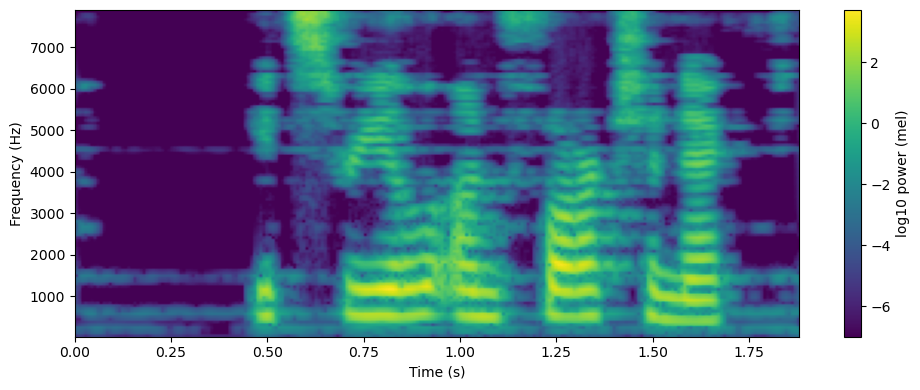

In [ ]:
melspec, t, f = plotMelSpectrogram(
    wav, 
    origSr = 22050, 
    targetSr = 16000, 
    nFft = 512, 
    nMels = 120, 
    device = wav.device 
)


In [613]:
print(len(wav1)/23)

22260.869565217392


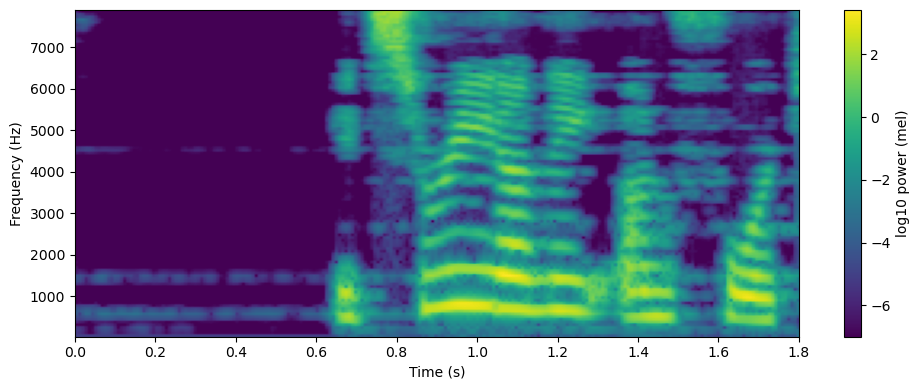

In [ ]:
melspec, t, f = plotMelSpectrogram(
    wav1[:int(22050 * 1.8)], 
    origSr = 22050, 
    targetSr = 16000, 
    nFft = 512, 
    nMels = 120, 
    device = wav.device  
)